# Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchmetrics import ConfusionMatrix
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import os
from tempfile import TemporaryDirectory
import numpy as np
from tqdm import tqdm

# Hyperparameters

In [2]:
batch_size = 8
epochs = 25
lr = 1e-3
device = "cuda"

# Prepare dataset

In [12]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_dir = 'data/Fumo'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(class_names)

['Cirno', 'Miku', 'Rei']


# Visualize dataset

In [ ]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
print(classes)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

#imshow(out, title=[class_names[x] for x in classes])

# Train func

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        losses = []
        accuracies = []

        for _ in tqdm(range(num_epochs)):
            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    losses.append(loss.item())
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                if phase == 'val':
                    epoch_acc = running_corrects.double() / dataset_sizes[phase]
                    accuracies.append(epoch_acc)

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, losses, accuracies

# Model

In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
for param in model_ft.parameters():
    param.requires_grad = False
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 3)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Train

### SGD + StepLR

In [ ]:
optimizer = optim.SGD(model_ft.parameters(), lr=lr, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_1, losses, accurs = train_model(model_ft, criterion, optimizer, scheduler, num_epochs=epochs)

In [ ]:
torch.save(model_1.state_dict(), "models_fe/model1.pt")

In [ ]:

plt.plot(losses)

plt.xlabel('Step')
plt.ylabel('Loss')

plt.show()
accurs_cpu = [acc.cpu() for acc in accurs]
plt.plot(accurs_cpu)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

### SGD + LinearLR

In [ ]:
optimizer = optim.SGD(model_ft.parameters(), lr=lr, momentum=0.9)
scheduler = lr_scheduler.LinearLR(optimizer, 1, 0.1, epochs)

model_2, losses, accurs = train_model(model_ft, criterion, optimizer, scheduler, num_epochs=epochs)

In [ ]:
torch.save(model_2.state_dict(), "models_fe/model2.pt")

In [ ]:
plt.plot(losses)

plt.xlabel('Step')
plt.ylabel('Loss')

plt.show()
accurs_cpu = [acc.cpu() for acc in accurs]
plt.plot(accurs_cpu)

plt.xlabel('Epoch')
plt.ylabel('Loss')

### AdamW + StepLR

In [ ]:
optimizer = optim.AdamW(model_ft.parameters(), lr=lr)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_3, losses, accurs = train_model(model_ft, criterion, optimizer, scheduler, num_epochs=epochs)

In [ ]:
torch.save(model_3.state_dict(), "models_fe/model3.pt")

In [ ]:
plt.plot(losses)

plt.xlabel('Step')
plt.ylabel('Loss')

plt.show()
accurs_cpu = [acc.cpu() for acc in accurs]
plt.plot(accurs_cpu)

plt.xlabel('Epoch')
plt.ylabel('Loss')

### AdamW + LinearLR

In [ ]:
optimizer = optim.AdamW(model_ft.parameters(), lr=lr)
scheduler = lr_scheduler.LinearLR(optimizer, 1, 0.1, epochs)

model_4, losses, accurs = train_model(model_ft, criterion, optimizer, scheduler, num_epochs=epochs)

In [ ]:
torch.save(model_4.state_dict(), "models_fe/model4.pt")

In [ ]:
plt.plot(losses)

plt.xlabel('Step')
plt.ylabel('Loss')

plt.show()
accurs_cpu = [acc.cpu() for acc in accurs]
plt.plot(accurs_cpu)

plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
%matplotlib qt

# Testing

In [ ]:
model_1 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_1.fc.in_features
model_1.fc = nn.Linear(num_ftrs, 3)
model_1.load_state_dict(torch.load("models_fe/model1.pt", weights_only=True))

model_2 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, 3)
model_2.load_state_dict(torch.load("models_fe/model2.pt", weights_only=True))

model_3= models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_3.fc.in_features
model_3.fc = nn.Linear(num_ftrs, 3)
model_3.load_state_dict(torch.load("models_fe/model3.pt", weights_only=True))

model_4 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_4.fc.in_features
model_4.fc = nn.Linear(num_ftrs, 3)
model_4.load_state_dict(torch.load("models_fe/model4.pt", weights_only=True))

<All keys matched successfully>

In [13]:
val_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=30,
                                             shuffle=True, num_workers=4)

In [ ]:
confmat = ConfusionMatrix(task="multiclass", num_classes=3).to(device)
softmax = nn.Softmax(dim=1)

### Model 1

In [ ]:
model_1.eval()
for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model_1(inputs)
    preds = torch.argmax(softmax(outputs), dim=1)
    print(inputs)
    conf_matrix = confmat(preds, labels)

    #print("Confusion Matrix:")
    #print(conf_matrix)

    for class_idx in range(3):
        TP = conf_matrix[class_idx, class_idx].item()  # Элемент на диагонали - TP для данного класса
        FN = conf_matrix[class_idx, :].sum().item() - TP  # Сумма строки без TP - FN
        FP = conf_matrix[:, class_idx].sum().item() - TP  # Сумма столбца без TP - FP
        TN = conf_matrix.sum().item() - (TP + FN + FP)  # Все остальное - TN

        print(f"\nClass {class_idx}:")
        print(f"True Positives (TP): {TP}")
        print(f"True Negatives (TN): {TN}")
        print(f"False Positives (FP): {FP}")
        print(f"False Negatives (FN): {FN}")

In [ ]:
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in labels])

### Model 2

In [ ]:
model_2.eval()
for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model_2(inputs)
    preds = torch.argmax(softmax(outputs), dim=1)
    conf_matrix = confmat(preds, labels)

    #print("Confusion Matrix:")
    #print(conf_matrix)

    for class_idx in range(3):
        TP = conf_matrix[class_idx, class_idx].item()  # Элемент на диагонали - TP для данного класса
        FN = conf_matrix[class_idx, :].sum().item() - TP  # Сумма строки без TP - FN
        FP = conf_matrix[:, class_idx].sum().item() - TP  # Сумма столбца без TP - FP
        TN = conf_matrix.sum().item() - (TP + FN + FP)  # Все остальное - TN

        print(f"\nClass {class_idx}:")
        print(f"True Positives (TP): {TP}")
        print(f"True Negatives (TN): {TN}")
        print(f"False Positives (FP): {FP}")
        print(f"False Negatives (FN): {FN}")

### Model 3

In [ ]:
model_3.eval()
for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model_3(inputs)
    preds = torch.argmax(softmax(outputs), dim=1)
    conf_matrix = confmat(preds, labels)

    #print("Confusion Matrix:")
    #print(conf_matrix)

    for class_idx in range(3):
        TP = conf_matrix[class_idx, class_idx].item()  # Элемент на диагонали - TP для данного класса
        FN = conf_matrix[class_idx, :].sum().item() - TP  # Сумма строки без TP - FN
        FP = conf_matrix[:, class_idx].sum().item() - TP  # Сумма столбца без TP - FP
        TN = conf_matrix.sum().item() - (TP + FN + FP)  # Все остальное - TN

        print(f"\nClass {class_idx}:")
        print(f"True Positives (TP): {TP}")
        print(f"True Negatives (TN): {TN}")
        print(f"False Positives (FP): {FP}")
        print(f"False Negatives (FN): {FN}")

### Model 4

In [ ]:
model_4.eval()
for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model_4(inputs)
    preds = torch.argmax(softmax(outputs), dim=1)
    print(preds.device)
    print(labels.device)
    conf_matrix = confmat(preds, labels)

    #print("Confusion Matrix:")
    #print(conf_matrix)

    for class_idx in range(3):
        TP = conf_matrix[class_idx, class_idx].item()  # Элемент на диагонали - TP для данного класса
        FN = conf_matrix[class_idx, :].sum().item() - TP  # Сумма строки без TP - FN
        FP = conf_matrix[:, class_idx].sum().item() - TP  # Сумма столбца без TP - FP
        TN = conf_matrix.sum().item() - (TP + FN + FP)  # Все остальное - TN

        print(f"\nClass {class_idx}:")
        print(f"True Positives (TP): {TP}")
        print(f"True Negatives (TN): {TN}")
        print(f"False Positives (FP): {FP}")
        print(f"False Negatives (FN): {FN}")

In [10]:
def visualize_model_predictions(dataloader, model, device='cuda' if torch.cuda.is_available() else 'cpu', 
                             class_names=None, num_samples=10):    
    # Переводим модель в режим оценки
    model.eval()
    model.to(device)
    
    # Получаем один батч из dataloader
    data_iter = iter(dataloader)
    images, true_labels = next(data_iter)
    
    # Определяем количество полных партий
    total_samples = len(images)
    num_batches = (total_samples + num_samples - 1) // num_samples  # Округление вверх
    
    # Обрабатываем каждую партию
    for batch_idx in range(num_batches):
        start_idx = batch_idx * num_samples
        end_idx = min(start_idx + num_samples, total_samples)
        current_batch_size = end_idx - start_idx
        
        # Перемещаем данные на устройство
        batch_images = images[start_idx:end_idx].to(device)
        
        # Получаем предсказания модели
        with torch.no_grad():
            logits = model(batch_images)
            probabilities = torch.softmax(logits, dim=1)
            predicted_labels = torch.argmax(probabilities, dim=1)
        
        # Создаем новую фигуру для текущей партии
        _, axes = plt.subplots(1, current_batch_size, figsize=(15, 5))
        
        # Обрабатываем каждое изображение в текущей партии
        for i in range(current_batch_size):
            # Получаем изображение
            image = batch_images[i].cpu()
            
            # Преобразуем тензор изображения в numpy array
            if image.shape[0] in [1, 3]:  # Проверяем, есть ли каналы
                image = image.permute(1, 2, 0)  # CHW -> HWC
            
            image = image.numpy()
            
            # Если изображение в оттенках серого (1 канал)
            if image.shape[-1] == 1:
                image = image.squeeze(-1)
                cmap = 'gray'
            else:
                cmap = None
            
            # Нормализуем изображение для отображения
            image = (image - image.min()) / (image.max() - image.min())
            
            # Отображаем изображение
            if current_batch_size == 1:
                axes.imshow(image, cmap=cmap)
                axes.axis('off')
            else:
                axes[i].imshow(image, cmap=cmap)
                axes[i].axis('off')
            
            # Определяем название для изображения
            pred_label = predicted_labels[i].item()
            true_label = true_labels[start_idx + i].item() if isinstance(true_labels[start_idx + i], torch.Tensor) else true_labels[start_idx + i]
            
            if class_names is not None:
                pred_title = class_names[pred_label]
                true_title = class_names[true_label]
            else:
                pred_title = str(pred_label)
                true_title = str(true_label)
            
            # Устанавливаем заголовок
            title = f'Pred: {pred_title}\nTrue: {true_title}'
            
            if current_batch_size == 1:
                axes.set_title(title)
            else:
                axes[i].set_title(title)
        
        plt.tight_layout()
        plt.show()

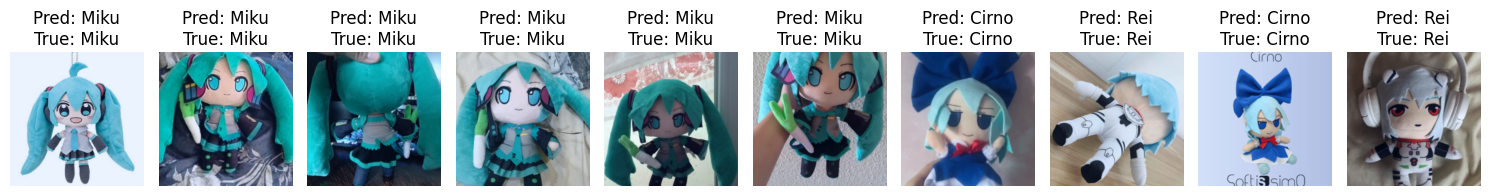

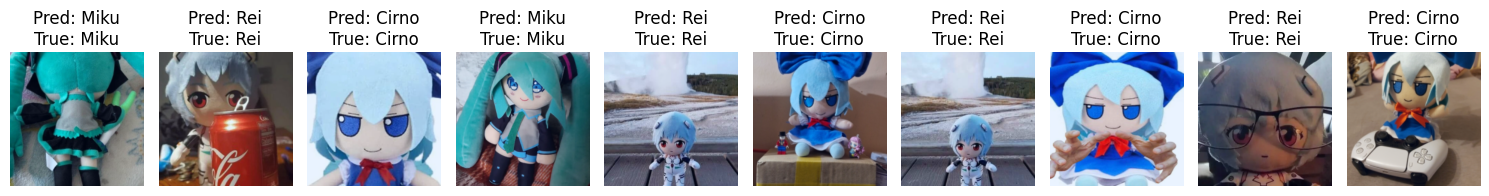

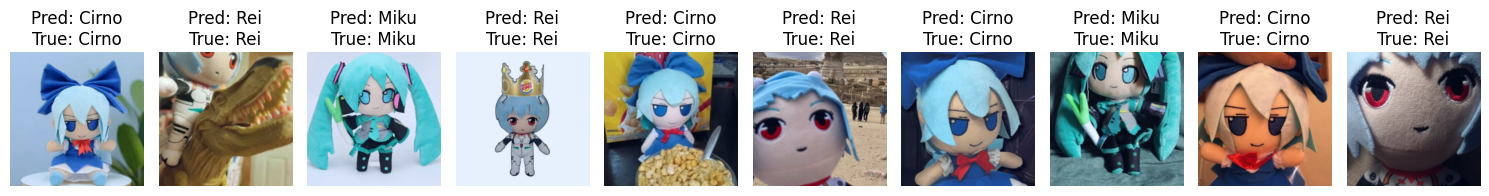

In [14]:
visualize_model_predictions(val_loader, model_1, "cuda", class_names=['Cirno', 'Miku', 'Rei'])